# Mercari Price Suggestion Challenge - 회귀 분석

참고 아티클: [Mercari Price Suggestion Challenge - A Deep Learning Regression Case Study](https://medium.com/@shivdutta/mercari-price-suggestion-challenge-a-deep-learning-regression-case-study-985ef2e560d)

이 노트북은 위 아티클의 접근 방식(전처리 → EDA → 피처 엔지니어링 → 베이스라인/비교 모델)을 참고하여 작성되었습니다.
모델링 범위: **Ridge 회귀(베이스라인) vs LightGBM(비교 모델)**

모든 중간 결과물(전처리 데이터, 벡터화 결과, 학습된 모델, 예측값, 평가지표)은 `results/` 폴더에 pickle로 저장하여
다음에 다시 불러와 확인할 수 있도록 합니다.

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn import set_config
# import lightgbm as lgb
import xgboost as xgb
from wordcloud import WordCloud

# estimator를 HTML(유니코드 특수문자)로 그리다가 cp949 인코딩 에러가 나는 것을 방지
set_config(display='text')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

# 결과 저장 폴더
RESULT_DIR = 'results'
FIG_DIR = os.path.join(RESULT_DIR, 'figures')
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

def save_pickle(obj, name):
    path = os.path.join(RESULT_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print('saved:', path)

def savefig(name):
    path = os.path.join(FIG_DIR, f'{name}.png')
    plt.tight_layout()
    plt.savefig(path, dpi=110)
    print('saved:', path)
    plt.show()

## 1. 데이터 로드

In [3]:
mercari_df = pd.read_csv('../../data/mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [ ]:
mercari_df.info()

## 2. 결측치 확인 (전처리 전)

`brand_name`, `category_name`, `item_description`에 결측치가 있는지 먼저 확인합니다.
아래 시각화가 **전처리 전** 상태이며, 5절에서 처리한 뒤 **전처리 후**와 비교합니다.

train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64
item_description == 'No description yet' (문자열): 82489
saved: results\figures\01_missing_before.png


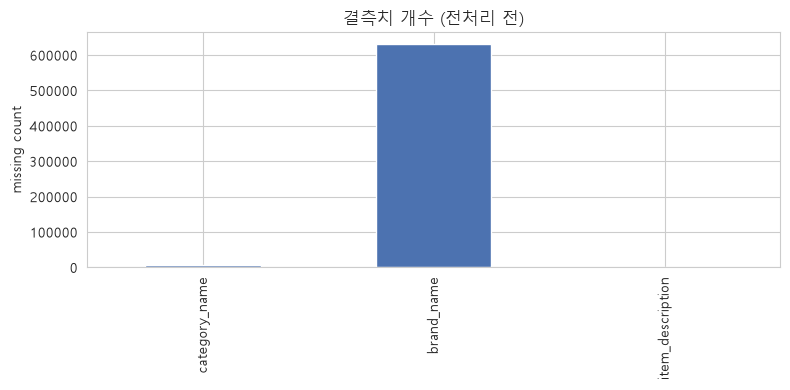

saved: results\missing_before.pkl


In [5]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

missing_before = mercari_df.isnull().sum()
print(missing_before)

# item_description은 NaN이 아니라 'No description yet' 라는 문자열로 채워진 경우도 많음
no_desc_literal = int((mercari_df['item_description'] == 'No description yet').sum())
print("item_description == 'No description yet' (문자열):", no_desc_literal)

plt.figure(figsize=(8, 4))
missing_before[missing_before > 0].plot(kind='bar', color='#4C72B0')
plt.title('결측치 개수 (전처리 전)')
plt.ylabel('missing count')
savefig('01_missing_before')

save_pickle({'missing_before': missing_before, 'no_desc_literal_before': no_desc_literal}, 'missing_before')

## 3. 가격(price) 분포 - 로그 변환 전/후 비교

`price`는 오른쪽으로 크게 치우친(right-skewed) 분포입니다. RMSLE 최적화 및 정규분포에 가까운 형태를 위해
`log1p` 변환을 적용하고, 변환 전/후 분포를 나란히 시각화하여 비교합니다.

왜도(skewness) - 원본: 11.393  ->  로그변환 후: 0.659


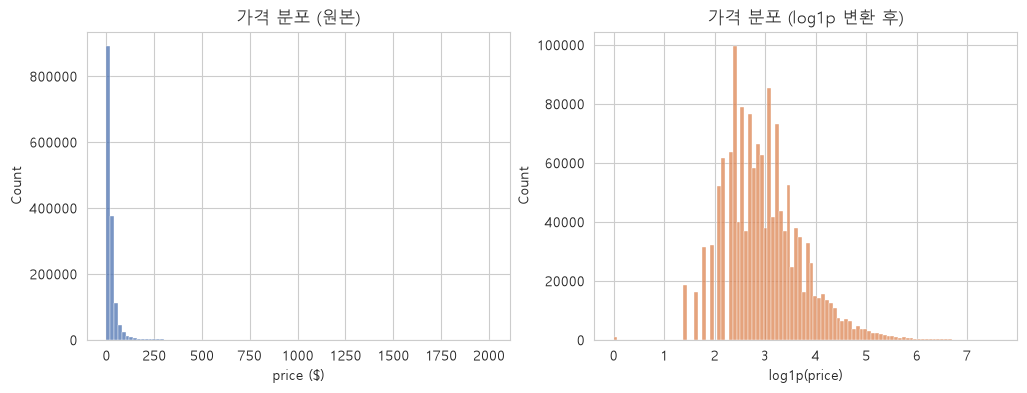

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(mercari_df['price'], bins=100, ax=axes[0], color='#4C72B0')
axes[0].set_title('가격 분포 (원본)')
axes[0].set_xlabel('price ($)')

mercari_df['log_price'] = np.log1p(mercari_df['price'])
sns.histplot(mercari_df['log_price'], bins=100, ax=axes[1], color='#DD8452')
axes[1].set_title('가격 분포 (log1p 변환 후)')
axes[1].set_xlabel('log1p(price)')

# savefig('02_price_distribution_before_after')

price_skew = mercari_df['price'].skew()
log_price_skew = mercari_df['log_price'].skew()
print(f'왜도(skewness) - 원본: {price_skew:.3f}  ->  로그변환 후: {log_price_skew:.3f}')

## 4. 탐색적 데이터 분석 (EDA)

saved: results\figures\03b_item_condition_count.png


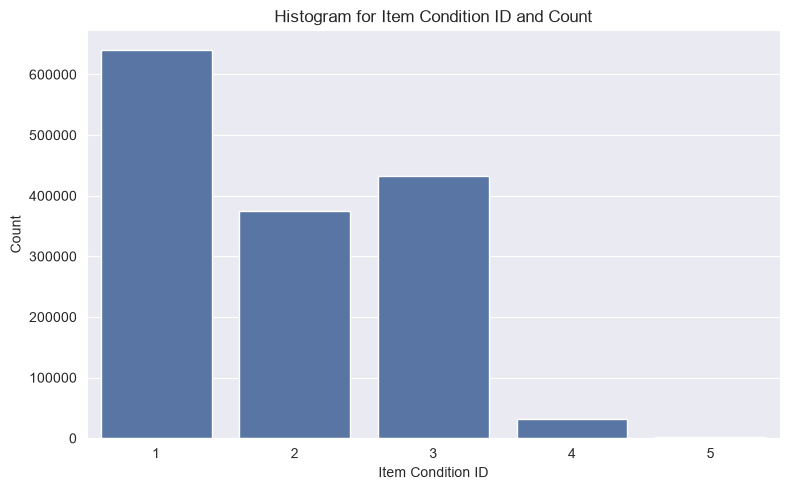

In [12]:
cond_counts = mercari_df['item_condition_id'].value_counts().sort_index()

with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(x=cond_counts.index, y=cond_counts.values, color='#4C72B0', ax=ax)
    ax.set_title('Histogram for Item Condition ID and Count')
    ax.set_xlabel('Item Condition ID')
    ax.set_ylabel('Count')

savefig('03b_item_condition_count')

saved: results\figures\03_condition_boxplot.png


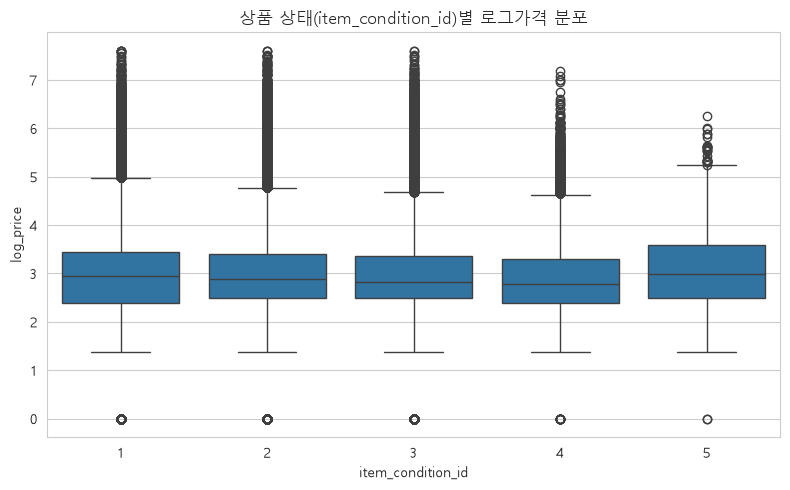

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=mercari_df, x='item_condition_id', y='log_price')
plt.title('상품 상태(item_condition_id)별 로그가격 분포')
savefig('03_condition_boxplot')

saved: results\figures\04_shipping_pdf.png


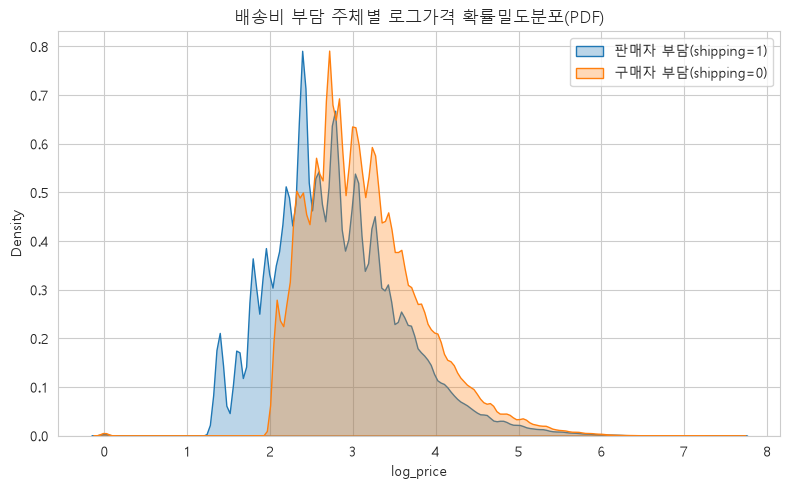

In [14]:
plt.figure(figsize=(8, 5))
for ship_val, label in [(1, '판매자 부담(shipping=1)'), (0, '구매자 부담(shipping=0)')]:
    subset = mercari_df.loc[mercari_df['shipping'] == ship_val, 'log_price']
    sns.kdeplot(subset, label=label, fill=True, alpha=0.3)
plt.legend()
plt.xlabel('log_price')
plt.ylabel('Density')
plt.title('배송비 부담 주체별 로그가격 확률밀도분포(PDF)')
savefig('04_shipping_pdf')

saved: results\figures\05_category_main_count.png


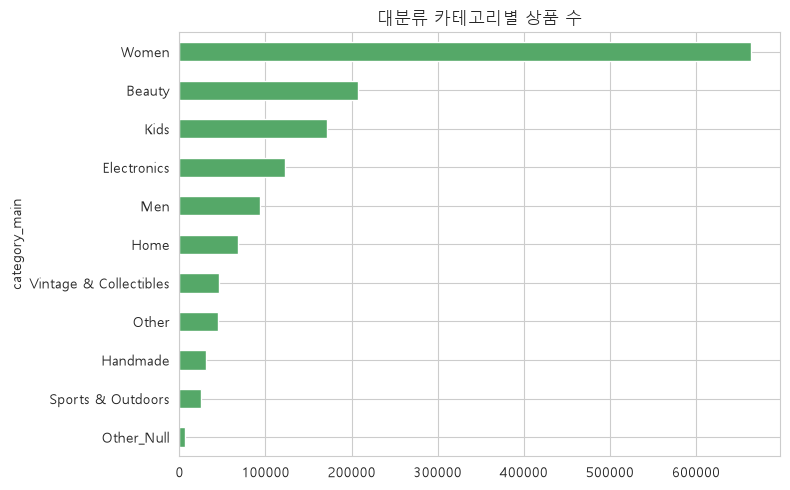

In [ ]:
def split_category(cat):
    if pd.isnull(cat):
        return ['Other_Null', 'Other_Null', 'Other_Null']
    parts = cat.split('/')
    parts = parts + ['Other_Null'] * (3 - len(parts))
    return parts[:3]

cats = mercari_df['category_name'].apply(split_category)
mercari_df['category_main'] = cats.apply(lambda x: x[0])
mercari_df['category_sub1'] = cats.apply(lambda x: x[1])
mercari_df['category_sub2'] = cats.apply(lambda x: x[2])

plt.figure(figsize=(8, 5))
mercari_df['category_main'].value_counts().plot(kind='barh', color='#55A868')
plt.title('대분류 카테고리별 상품 수')
plt.gca().invert_yaxis()
savefig('05_category_main_count')

# 여성 관련 제품이 압도적으로 많음

saved: results\figures\06_brand_top10.png


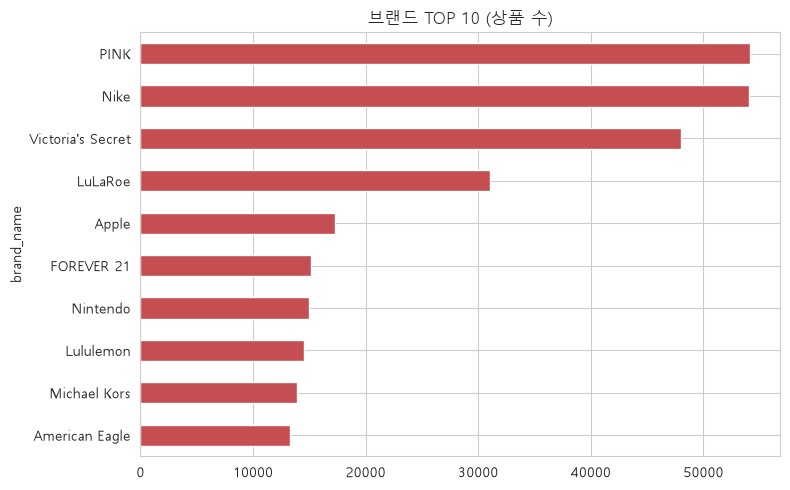

In [10]:
plt.figure(figsize=(8, 5))
mercari_df['brand_name'].value_counts().head(10).plot(kind='barh', color='#C44E52')
plt.title('브랜드 TOP 10 (상품 수)')
plt.gca().invert_yaxis()
savefig('06_brand_top10')

saved: results\figures\07_wordcloud_name.png


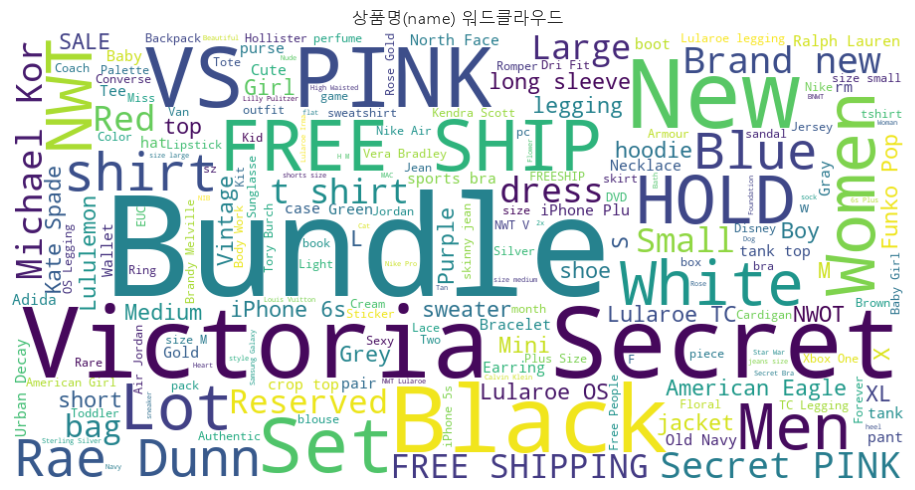

In [11]:
sample_n = min(200000, len(mercari_df))
text_for_wc = ' '.join(mercari_df['name'].dropna().sample(sample_n, random_state=42).astype(str))
wc = WordCloud(width=900, height=450, background_color='white').generate(text_for_wc)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('상품명(name) 워드클라우드')
savefig('07_wordcloud_name')

## 5. 결측치 처리 (전처리) - 전/후 비교 완성

- `brand_name`, `category_main/sub1/sub2` 결측 -> `'Other_Null'`
- `item_description` 결측 -> `'No description yet'` (기존 placeholder 문자열과 통일)

처리 후 결측치 개수를 다시 집계하여 **2절(전처리 전)**과 비교합니다.

brand_name          0
category_main       0
category_sub1       0
category_sub2       0
item_description    0
dtype: int64
saved: results\figures\08_missing_after.png


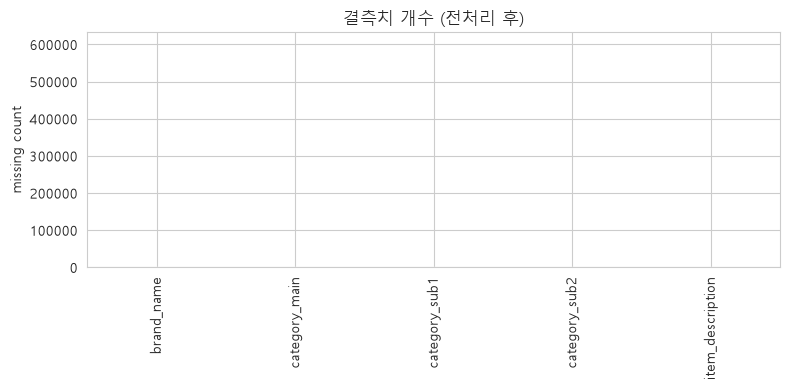

saved: results\missing_after.pkl
saved: results\mercari_df_preprocessed.pkl


In [15]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna('Other_Null')
mercari_df['category_main'] = mercari_df['category_main'].fillna('Other_Null')
mercari_df['category_sub1'] = mercari_df['category_sub1'].fillna('Other_Null')
mercari_df['category_sub2'] = mercari_df['category_sub2'].fillna('Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna('No description yet')

check_cols = ['brand_name', 'category_main', 'category_sub1', 'category_sub2', 'item_description']
missing_after = mercari_df[check_cols].isnull().sum()
print(missing_after)

plt.figure(figsize=(8, 4))
missing_after.plot(kind='bar', color='#55A868')
plt.title('결측치 개수 (전처리 후)')
plt.ylabel('missing count')
plt.ylim(0, max(1, int(missing_before.max())))
savefig('08_missing_after')

save_pickle(missing_after, 'missing_after')
save_pickle(mercari_df, 'mercari_df_preprocessed')

## 6. 텍스트 결합 및 길이 파생 피처

saved: results\figures\09_textlen_vs_logprice.png


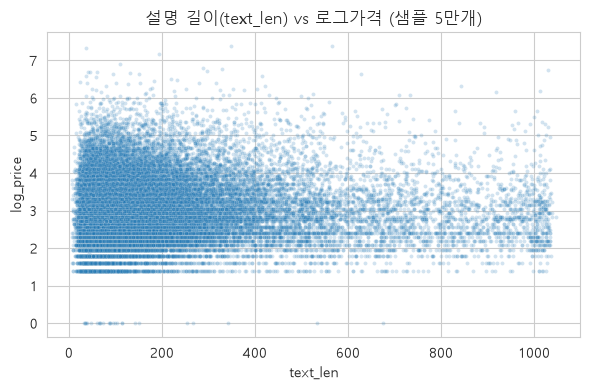

In [16]:
mercari_df['text'] = mercari_df['name'].fillna('') + ' ' + mercari_df['item_description'].fillna('')
mercari_df['text_len'] = mercari_df['text'].str.len()

plt.figure(figsize=(6, 4))
sample_plot = mercari_df.sample(min(50000, len(mercari_df)), random_state=42)
sns.scatterplot(data=sample_plot, x='text_len', y='log_price', alpha=0.2, s=8)
plt.title('설명 길이(text_len) vs 로그가격 (샘플 5만개)')
savefig('09_textlen_vs_logprice')

## 7. 피처 엔지니어링 (벡터화)

- `name` -> `CountVectorizer` (unigram)
- `item_description` -> `TfidfVectorizer` (1~3gram, max_features=50000, stop_words='english')
- `brand_name`, `category_main/sub1/sub2`, `item_condition_id`, `shipping` -> `LabelBinarizer(sparse_output=True)`
- 위 모든 희소 행렬을 `scipy.sparse.hstack`으로 결합

> 주의: `name` 벡터화는 148만 행 전체를 대상으로 하므로 몇 분 정도 소요될 수 있습니다.

In [ ]:
cnt_vec_name = CountVectorizer()
X_name = cnt_vec_name.fit_transform(mercari_df['name'])
print('X_name shape:', X_name.shape)

tfidf_vec_descp = TfidfVectorizer(max_features=50000, ngram_range=(1, 3), stop_words='english')
X_descp = tfidf_vec_descp.fit_transform(mercari_df['item_description'])
print('X_descp shape:', X_descp.shape)

# X_name shape: (1482535, 105757)
# X_descp shape: (1482535, 50000)

X_name shape: (1482535, 105757)
X_descp shape: (1482535, 50000)


In [18]:
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])

lb_category_main = LabelBinarizer(sparse_output=True)
X_category_main = lb_category_main.fit_transform(mercari_df['category_main'])

lb_category_sub1 = LabelBinarizer(sparse_output=True)
X_category_sub1 = lb_category_sub1.fit_transform(mercari_df['category_sub1'])

lb_category_sub2 = LabelBinarizer(sparse_output=True)
X_category_sub2 = lb_category_sub2.fit_transform(mercari_df['category_sub2'])

lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])

lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

print('브랜드 클래스 수:', len(lb_brand_name.classes_))
print('대분류 카테고리 클래스 수:', len(lb_category_main.classes_))

브랜드 클래스 수: 4810
대분류 카테고리 클래스 수: 11


In [19]:
X_features_sparse = hstack([
    X_name, X_descp, X_brand, X_category_main, X_category_sub1,
    X_category_sub2, X_item_cond_id, X_shipping
]).tocsr()

print('X_features_sparse shape:', X_features_sparse.shape)

save_pickle(X_features_sparse, 'X_features_sparse')
save_pickle({
    'cnt_vec_name': cnt_vec_name,
    'tfidf_vec_descp': tfidf_vec_descp,
    'lb_brand_name': lb_brand_name,
    'lb_category_main': lb_category_main,
    'lb_category_sub1': lb_category_sub1,
    'lb_category_sub2': lb_category_sub2,
    'lb_item_cond_id': lb_item_cond_id,
    'lb_shipping': lb_shipping,
}, 'vectorizers')

X_features_sparse shape: (1482535, 161569)
saved: results\X_features_sparse.pkl
saved: results\vectorizers.pkl


## 8. 평가 지표: RMSLE

$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\log(1+\hat{y}_i) - \log(1+y_i))^2}$$

타깃(`log_price`)을 이미 `log1p`로 변환해두었기 때문에, 로그 스케일에서의 RMSE를 계산하면 그대로 RMSLE가 됩니다.

In [20]:
def rmsle(y_true_log, y_pred_log):
    # y가 이미 log1p 스케일이면 RMSE == RMSLE
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

## 9. 기준 모델 (Ridge 회귀)

In [ ]:
y_target = mercari_df['log_price']
X_train, X_test, y_train, y_test = train_test_split(
    X_features_sparse, y_target, test_size=0.2, random_state=156
)
print('train:', X_train.shape, ' test:', X_test.shape)
# train: (1186028, 161569)  test: (296507, 161569)

train: (1186028, 161569)  test: (296507, 161569)


In [ ]:
import time
t0 = time.time()

ridge_model = Ridge(solver='lsqr', fit_intercept=False, alpha=3)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
ridge_rmsle = rmsle(y_test, ridge_pred)
ridge_time = time.time() - t0

print(f'Ridge RMSLE: {ridge_rmsle:.5f}  (학습시간 {ridge_time:.1f}초)')

save_pickle(ridge_model, 'ridge_model')
save_pickle(ridge_pred, 'ridge_pred')
# Ridge RMSLE: 0.46525  (학습시간 42.7초)

Ridge RMSLE: 0.46525  (학습시간 42.7초)
saved: results\ridge_model.pkl
saved: results\ridge_pred.pkl


## 10. 비교 모델 (LightGBM)

트리 기반 부스팅 모델인 LightGBM으로 동일한 피처를 학습시켜 Ridge와 성능을 비교합니다.
고차원 희소 행렬(수만~수십만 컬럼)이라 Ridge보다 학습 시간이 오래 걸릴 수 있습니다.

In [24]:
import xgboost as xgb

t0 = time.time()

xgb_model = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.1, num_leaves=125,
    n_jobs=-1, random_state=156
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_rmsle = rmsle(y_test, xgb_pred)
xgb_time = time.time() - t0

print(f'LightGBM RMSLE: {xgb_rmsle:.5f}  (학습시간 {xgb_time:.1f}초)')

save_pickle(xgb_model, 'xgb_model')
save_pickle(xgb_pred, 'xgb_pred')

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:25:21] WARNING: C:\Users\task_177740979073858\croot\xgboost-split_1777409985184\work\src\learner.cc:782: 
Parameters: { "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


LightGBM RMSLE: 0.54707  (학습시간 704.0초)
saved: results\xgb_model.pkl
saved: results\xgb_pred.pkl


## 11. 모델 비교 및 최종 결과 저장

saved: results\figures\10_model_rmsle_comparison.png


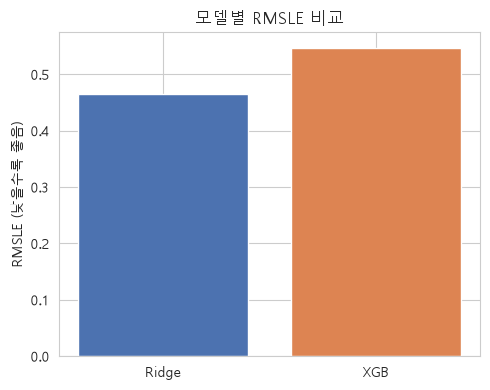

Ridge    RMSLE: 0.46525
LightGBM RMSLE: 0.54707


In [25]:
plt.figure(figsize=(5, 4))
plt.bar(['Ridge', 'XGB'], [ridge_rmsle, xgb_rmsle], color=['#4C72B0', '#DD8452'])
plt.ylabel('RMSLE (낮을수록 좋음)')
plt.title('모델별 RMSLE 비교')
savefig('10_model_rmsle_comparison')

print(f'Ridge    RMSLE: {ridge_rmsle:.5f}')
print(f'LightGBM RMSLE: {xgb_rmsle:.5f}')

In [26]:
results_summary = {
    'data_shape': mercari_df.shape,
    'price_skew_before': float(price_skew),
    'price_skew_after_log': float(log_price_skew),
    'X_features_sparse_shape': X_features_sparse.shape,
    'n_brand_classes': len(lb_brand_name.classes_),
    'n_category_main_classes': len(lb_category_main.classes_),
    'ridge_rmsle': float(ridge_rmsle),
    'ridge_train_time_sec': ridge_time,
    'lgbm_rmsle': float(xgb_rmsle),
    'lgbm_train_time_sec': xgb_rmsle,
}
save_pickle(results_summary, 'results_summary')
results_summary

saved: results\results_summary.pkl


{'data_shape': (1482535, 14),
 'price_skew_before': 11.393232000122508,
 'price_skew_after_log': 0.659423201880768,
 'X_features_sparse_shape': (1482535, 161569),
 'n_brand_classes': 4810,
 'n_category_main_classes': 11,
 'ridge_rmsle': 0.4652522818150783,
 'ridge_train_time_sec': 42.652426958084106,
 'lgbm_rmsle': 0.5470682135994803,
 'lgbm_train_time_sec': np.float64(0.5470682135994803)}

## 정리

- 모든 중간 산출물은 `03_회귀/results/*.pkl` 로 저장되어 있어 커널을 새로 켜도 아래처럼 바로 불러올 수 있습니다.

```python
import pickle
with open('results/results_summary.pkl', 'rb') as f:
    summary = pickle.load(f)
summary
```

- 그래프 원본 이미지는 `03_회귀/results/figures/` 에 PNG로 저장되어 있어 보고서에 바로 삽입할 수 있습니다.